# Aplicación de Random Forest

In [1]:
# ── Librerías estándar ────────────────────────────────────────────────────────
import os
import time
import warnings
import json
from collections import Counter

# ── Datos ────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualización ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# ── Scikit-learn ──────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    OrdinalEncoder, StandardScaler, LabelEncoder, OneHotEncoder
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, f1_score, precision_score, recall_score
)
from sklearn.utils.class_weight import compute_class_weight

# ── XGBoost ───────────────────────────────────────────────────────────────────
from xgboost import XGBClassifier
import xgboost as xgb

# ── TensorFlow / Keras ────────────────────────────────────────────────────────
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

# ── API Socrata ───────────────────────────────────────────────────────────────
from sodapy import Socrata

# ── Configuraciones globales ──────────────────────────────────────────────────
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.4f}'.format)
np.random.seed(42)
tf.random.set_seed(42)

sns.set_theme(style='whitegrid', palette='Set2', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 110, 'figure.figsize': (10, 5)})

print('✅ Entorno configurado.')
print(f'   NumPy:       {np.__version__}')
print(f'   Pandas:      {pd.__version__}')
print(f'   XGBoost:     {xgb.__version__}')
print(f'   TensorFlow:  {tf.__version__}')


✅ Entorno configurado.
   NumPy:       2.3.2
   Pandas:      2.3.2
   XGBoost:     3.1.0
   TensorFlow:  2.21.0


In [2]:
# ── Parámetros de descarga ────────────────────────────────────────────────────
DATASET_ID = 'kgxf-xxbe'
PAGE_SIZE  = 10_000
RAW_PATH   = 'saber11_20221_20224.parquet'
PERIODOS   = ['20221', '20224']   # ÚNICAMENTE estos dos períodos

print(f'Dataset ID : {DATASET_ID}')
print(f'Page size  : {PAGE_SIZE:,} registros/bloque')
print(f'Caché path : {RAW_PATH}')
print(f'Períodos   : {PERIODOS}')


Dataset ID : kgxf-xxbe
Page size  : 10,000 registros/bloque
Caché path : saber11_20221_20224.parquet
Períodos   : ['20221', '20224']


In [3]:
# ── Descarga paginada por período ────────────────────────────────────────────
if os.path.exists(RAW_PATH):
    print(f'📂 Cargando desde caché: {RAW_PATH}')
    df_raw = pd.read_parquet(RAW_PATH)
else:
    print('🌐 Conectando a la API de datos.gov.co...')
    client = Socrata(
        'www.datos.gov.co',
        None,          # acceso anónimo (lectura pública)
        timeout=300
    )
    all_records = []

    for periodo in PERIODOS:
        print(f'\n📥 Descargando período {periodo}...')
        offset, total_periodo = 0, 0

        while True:
            try:
                batch = client.get(
                    DATASET_ID,
                    where=f"periodo = '{periodo}'",
                    limit=PAGE_SIZE,
                    offset=offset
                )
            except Exception as e:
                print(f'⚠️  Error en offset {offset}: {e} — reintentando en 5 s...')
                time.sleep(5)
                batch = client.get(
                    DATASET_ID,
                    where=f"periodo = '{periodo}'",
                    limit=PAGE_SIZE,
                    offset=offset
                )

            if not batch:
                print(f'✅ Fin de descarga para {periodo}')
                break

            all_records.extend(batch)
            batch_size     = len(batch)
            total_periodo += batch_size
            offset        += PAGE_SIZE

            print(f'   ✔ {periodo} | batch={batch_size:,} | acum={total_periodo:,}')

            if batch_size < PAGE_SIZE:
                print(f'✅ Último bloque para {periodo}')
                break
            time.sleep(0.5)

    df_raw = pd.DataFrame.from_records(all_records)
    df_raw.to_parquet(RAW_PATH, index=False)
    print(f'\n✅ {len(df_raw):,} registros guardados en "{RAW_PATH}"')

# ── Resumen ───────────────────────────────────────────────────────────────────
print(f'\n📊 Dimensiones: {df_raw.shape[0]:,} filas × {df_raw.shape[1]} columnas')
print('\n📌 Registros por período:')
display(
    df_raw['periodo']
    .value_counts()
    .sort_index(ascending=False)
    .rename('Registros')
    .to_frame()
    .assign(Porcentaje_pct=lambda x: (x['Registros'] / x['Registros'].sum() * 100).round(2))
)


📂 Cargando desde caché: saber11_20221_20224.parquet

📊 Dimensiones: 1,085,937 filas × 51 columnas

📌 Registros por período:


,Registros,Porcentaje_pct
periodo,,
20224,1065888,98.1500
20221,20049,1.8500


## Definición de variables objetivo

In [4]:
# ── Variable objetivo ────────────────────────────────────────────────────────
df = df_raw.copy()
df['punt_global'] = pd.to_numeric(df['punt_global'], errors='coerce')

#LABELS = ['Muy Bajo', 'Bajo', 'Aceptable', 'Bueno', 'Excelente']
#BINS   = [0, 232, 270, 310, 360, 500]

LABELS = ['Bajo', 'Básico', 'Alto']
BINS   = [0, 225, 335, 500]

df['nivel_desempeno'] = pd.cut(
    df['punt_global'], bins=BINS, labels=LABELS,
    include_lowest=True, right=True
)

print('✅ Variable objetivo creada: nivel_desempeno')
dist = df['nivel_desempeno'].value_counts().reindex(LABELS)
pct  = (dist / dist.sum() * 100).round(2)
display(pd.DataFrame({'Clase': LABELS, 'Conteo': dist.values, '% Total': pct.values}))


✅ Variable objetivo creada: nivel_desempeno


,Clase,Conteo,% Total
0,Bajo,383754,35.3400
1,Básico,634657,58.4400
2,Alto,67526,6.2200


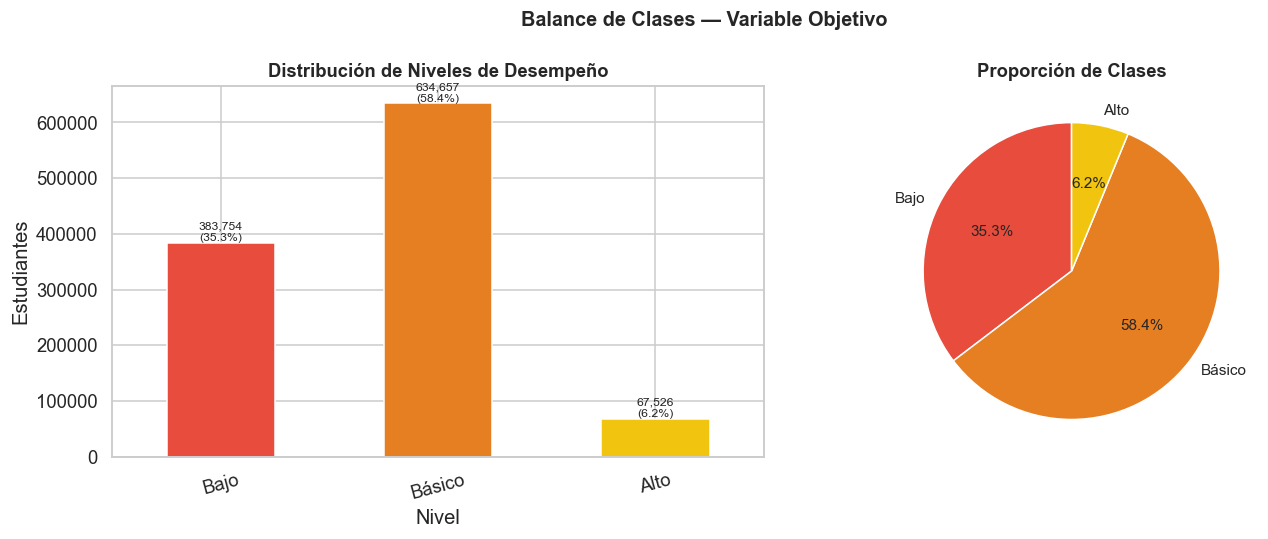

In [5]:
# ── Visualización del balance de clases ──────────────────────────────────────
#COLORES = ['#E74C3C', '#E67E22', '#F1C40F', '#2ECC71', '#3498DB']
COLORES = ['#E74C3C', '#E67E22', '#F1C40F']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Barras
dist.plot(kind='bar', ax=axes[0], color=COLORES, edgecolor='white')
axes[0].set_title('Distribución de Niveles de Desempeño',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Nivel'); axes[0].set_ylabel('Estudiantes')
axes[0].tick_params(axis='x', rotation=15)
total_p = dist.sum()
for bar in axes[0].patches:
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + total_p * 0.003,
        f'{bar.get_height():,}\n({bar.get_height()/total_p*100:.1f}%)',
        ha='center', fontsize=8
    )

# Pie
dist.plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
          colors=COLORES, startangle=90, textprops={'fontsize': 10})
axes[1].set_title('Proporción de Clases', fontsize=12, fontweight='bold')
axes[1].set_ylabel('')

plt.suptitle('Balance de Clases — Variable Objetivo', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('images/fig_balance_clases.png', dpi=110, bbox_inches='tight')
plt.show()


In [6]:
# ── Definición de columnas ────────────────────────────────────────────────────
SCORE_COLS = [c for c in ['punt_ingles','punt_matematicas','punt_c_naturales',
                            'punt_sociales_ciudadanas','punt_lectura_critica','punt_global']
              if c in df_raw.columns]

EXCLUDE_COLS = SCORE_COLS + [
    'estu_consecutivo',
    'periodo',
    'nivel_desempeno',
    'cole_cod_depto_ubicacion',

    # =========================
    # Variables adicionales
    # =========================
    'estu_tipodocumento',
    'cole_cod_mcpio_ubicacion',
    'cole_cod_departamento_unicacion',
    'cole_codigo_icfes',
    'cole_nombre_establecimiento',
    'cole_nombre_sede',
    'estu_cod_depto_presentacion',
    'estu_cod_mcpio_presentacion',
    'estu_cod_reside_mcpio',
    'estu_fechanacimiento',
    'estu_mcpio_presentacion',
    'estu_mcpio_reside',
    'estu_pais_reside',
    'desemp_ingles',
    'cole_mcpio_ubicacion',
    'cole_codigo_icfes',
    'cole_cod_dane_sede',
    'cole_cod_dane_establecimiento',
    'estu_cod_mcpio_presentacion'
]


TARGET       = 'nivel_desempeno'

# Excluir variables de alta cardinalidad (>200 categorías → problemas de memoria/encoding)
alta_card = []
for col in df.columns:
    if col not in EXCLUDE_COLS and df[col].dtype == object:
        if df[col].nunique() > 200:
            alta_card.append(col)
            EXCLUDE_COLS.append(col)

if alta_card:
    print(f'⚠️  Excluidas por alta cardinalidad (>{200} cat.): {alta_card}')

FEATURES     = [c for c in df.columns if c not in EXCLUDE_COLS]
NUM_FEATURES = df[FEATURES].select_dtypes(include='number').columns.tolist()
CAT_FEATURES = df[FEATURES].select_dtypes(include=['object','category']).columns.tolist()

print(f'\nTotal features: {len(FEATURES)}')
print(f'  → Numéricas  : {len(NUM_FEATURES)} → {NUM_FEATURES}')
print(f'  → Categóricas: {len(CAT_FEATURES)} → {CAT_FEATURES}')



Total features: 26
  → Numéricas  : 0 → []
  → Categóricas: 26 → ['cole_area_ubicacion', 'cole_calendario', 'cole_caracter', 'cole_depto_ubicacion', 'cole_genero', 'cole_jornada', 'cole_naturaleza', 'cole_sede_principal', 'estu_cod_reside_depto', 'estu_depto_presentacion', 'estu_depto_reside', 'estu_estadoinvestigacion', 'estu_estudiante', 'estu_genero', 'estu_nacionalidad', 'estu_privado_libertad', 'fami_cuartoshogar', 'fami_educacionmadre', 'fami_educacionpadre', 'fami_estratovivienda', 'fami_personashogar', 'fami_tieneautomovil', 'fami_tienecomputador', 'fami_tieneinternet', 'fami_tienelavadora', 'cole_bilingue']


### 5.3 Limpieza Pre-Modelado: Duplicados y Registros Sin Target

In [7]:
# ── Eliminar duplicados (estu_consecutivo) ────────────────────────────────────
n_antes = len(df)
df = df[~df.duplicated(subset=['estu_consecutivo'], keep='first')].reset_index(drop=True)
print(f'Registros eliminados por duplicado: {n_antes - len(df):,}')

# ── Eliminar filas sin nivel_desempeno (sin punt_global válido) ────────────────
df = df.dropna(subset=['nivel_desempeno']).reset_index(drop=True)
print(f'Registros con target válido: {len(df):,}')

# ── Codificación numérica del target ──────────────────────────────────────────
label2idx = {l: i for i, l in enumerate(LABELS)}
df['target'] = df['nivel_desempeno'].map(label2idx)

print('\nCodificación del target:')
for l, i in label2idx.items():
    print(f'  {i} → {l}')


Registros eliminados por duplicado: 533,096
Registros con target válido: 552,841

Codificación del target:
  0 → Bajo
  1 → Básico
  2 → Alto


## Para dos experimentos de eliminación e imputación

In [8]:
# ── Subsets por experimento ───────────────────────────────────────────────────
X_all = df[FEATURES].copy()
y_all = df['target'].copy()

# Experimento 1: solo filas completamente limpias
mask_clean = X_all.notna().all(axis=1)
X_exp1, y_exp1 = X_all[mask_clean].reset_index(drop=True), y_all[mask_clean].reset_index(drop=True)

# Experimento 2: dataset completo (con nulos — se imputará en el pipeline)
X_exp2, y_exp2 = X_all.copy(), y_all.copy()

print(f'Exp 1 (Eliminación): {len(X_exp1):,} registros ({len(X_exp1)/len(X_all)*100:.1f}%)')
print(f'Exp 2 (Imputación):  {len(X_exp2):,} registros ({len(X_exp2)/len(X_all)*100:.1f}%)')


Exp 1 (Eliminación): 406,448 registros (73.5%)
Exp 2 (Imputación):  552,841 registros (100.0%)


In [9]:
# ── División Train / Test estratificada (80/20) ────────────────────────────────
RANDOM_STATE = 42

X_tr1, X_te1, y_tr1, y_te1 = train_test_split(
    X_exp1, y_exp1, test_size=0.20, random_state=RANDOM_STATE, stratify=y_exp1
)
X_tr2, X_te2, y_tr2, y_te2 = train_test_split(
    X_exp2, y_exp2, test_size=0.20, random_state=RANDOM_STATE, stratify=y_exp2
)

print('División Train / Test (80/20, estratificada):')
print(f'  Exp 1 → Train: {len(X_tr1):,}  |  Test: {len(X_te1):,}')
print(f'  Exp 2 → Train: {len(X_tr2):,}  |  Test: {len(X_te2):,}')


División Train / Test (80/20, estratificada):
  Exp 1 → Train: 325,158  |  Test: 81,290
  Exp 2 → Train: 442,272  |  Test: 110,569


In [10]:
# Experimento 1: sin imputación (datos ya limpios)
proc_e1 = ColumnTransformer([
    ('num', StandardScaler(), NUM_FEATURES),
    ('cat', OneHotEncoder(handle_unknown='ignore'), CAT_FEATURES)
], remainder='drop')

# Experimento 2: con imputación antes de escalar/codificar
proc_e2 = ColumnTransformer([
    ('num', Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('sc',  StandardScaler())
    ]), NUM_FEATURES),

    ('cat', Pipeline([
        ('imp', SimpleImputer(strategy='most_frequent')),
        ('enc', OneHotEncoder(handle_unknown='ignore'))
    ]), CAT_FEATURES)

], remainder='drop')

print('✅ Preprocesadores definidos.')
print('  Exp 1: StandardScaler + OneHotEncoder (sin imputación)')
print('  Exp 2: SimpleImputer(median/moda) + StandardScaler + OneHotEncoder')

✅ Preprocesadores definidos.
  Exp 1: StandardScaler + OneHotEncoder (sin imputación)
  Exp 2: SimpleImputer(median/moda) + StandardScaler + OneHotEncoder


In [11]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


def evaluar(nombre, y_true, y_pred, y_prob=None, labels=None):
    """
    Calcula y muestra métricas completas de clasificación multiclase.

    Parámetros:
    -----------
    nombre  : str
    y_true  : array
    y_pred  : array
    y_prob  : array opcional (predict_proba)
    labels  : lista opcional de nombres de clases

    Retorna:
    --------
    dict con métricas
    """

    # ── Métricas principales ────────────────────────────────────────────────
    acc  = accuracy_score(y_true, y_pred)

    f1m  = f1_score(
        y_true, y_pred,
        average='macro',
        zero_division=0
    )

    f1w  = f1_score(
        y_true, y_pred,
        average='weighted',
        zero_division=0
    )

    prec = precision_score(
        y_true, y_pred,
        average='macro',
        zero_division=0
    )

    rec  = recall_score(
        y_true, y_pred,
        average='macro',
        zero_division=0
    )

    # ── ROC AUC ─────────────────────────────────────────────────────────────
    auc = None

    if y_prob is not None:
        try:
            auc = roc_auc_score(
                y_true,
                y_prob,
                multi_class='ovr',
                average='macro'
            )
        except Exception as e:
            print(f'⚠️ No se pudo calcular ROC-AUC: {e}')

    # ── Mostrar métricas ────────────────────────────────────────────────────
    print(f'\n{"═"*58}')
    print(f'  {nombre}')
    print(f'{"═"*58}')

    print(f'  Accuracy            : {acc:.4f}')
    print(f'  F1-score (macro)    : {f1m:.4f}')
    print(f'  F1-score (weighted) : {f1w:.4f}')
    print(f'  Precision (macro)   : {prec:.4f}')
    print(f'  Recall (macro)      : {rec:.4f}')

    if auc is not None:
        print(f'  ROC-AUC (OvR macro) : {auc:.4f}')

    print()

    # ── Labels dinámicos ────────────────────────────────────────────────────
    if labels is None:
        labels = sorted(np.unique(y_true))

    print(
        classification_report(
            y_true,
            y_pred,
            target_names=[str(x) for x in labels],
            zero_division=0
        )
    )

    # ── Matriz de confusión ─────────────────────────────────────────────────
    cm = confusion_matrix(y_true, y_pred)

    fig, ax = plt.subplots(figsize=(7, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        ax=ax,
        xticklabels=labels,
        yticklabels=labels,
        linewidths=0.4
    )

    ax.set_title(
        f'Matriz de Confusión — {nombre}',
        fontsize=12,
        fontweight='bold',
        pad=10
    )

    ax.set_xlabel('Predicción', fontsize=11)
    ax.set_ylabel('Real', fontsize=11)

    plt.xticks(rotation=30, ha='right')
    plt.yticks(rotation=0)

    plt.tight_layout()

    fn = (
        f'images/fig_cm_'
        f'{nombre.replace(" ","_").replace("(","").replace(")","").lower()}.png'
    )

    plt.savefig(fn, dpi=110, bbox_inches='tight')

    plt.show()

    # ── Retorno ─────────────────────────────────────────────────────────────
    return {
        'modelo': nombre,
        'accuracy': acc,
        'f1_macro': f1m,
        'f1_weighted': f1w,
        'precision_macro': prec,
        'recall_macro': rec,
        'roc_auc': auc
    }


print('✅ Función evaluar() definida.')

✅ Función evaluar() definida.


### Aplicación de modelo Random Forest - Eliminación de nulos

🚀 Random Forest — Exp 1 (Eliminación)...

══════════════════════════════════════════════════════════
  RF — Exp 1 (Elim.)
══════════════════════════════════════════════════════════
  Accuracy            : 0.5191
  F1-score (macro)    : 0.4824
  F1-score (weighted) : 0.5276
  Precision (macro)   : 0.4835
  Recall (macro)      : 0.5921
  ROC-AUC (OvR macro) : 0.7403

              precision    recall  f1-score   support

           0       0.50      0.69      0.58     26071
           1       0.72      0.41      0.52     49326
           2       0.23      0.68      0.34      5893

    accuracy                           0.52     81290
   macro avg       0.48      0.59      0.48     81290
weighted avg       0.61      0.52      0.53     81290



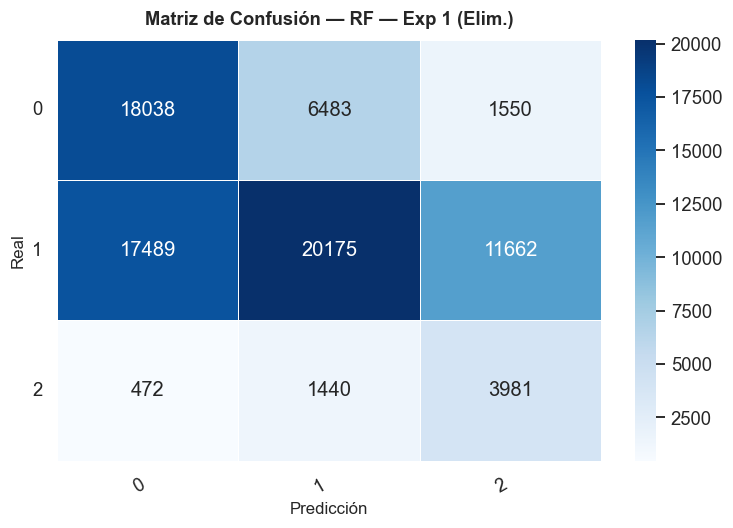

In [12]:
# ── RF — Exp 1 ───────────────────────────────────────────────────────────────
print('🚀 Random Forest — Exp 1 (Eliminación)...')
pipe_rf1 = Pipeline([
    ('prep', clone(proc_e1)),
    ('clf',  RandomForestClassifier(
        n_estimators=300, max_depth=15, min_samples_leaf=10,
        class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
    ))
])
pipe_rf1.fit(X_tr1, y_tr1)
yp_rf1  = pipe_rf1.predict(X_te1)
ypr_rf1 = pipe_rf1.predict_proba(X_te1)
met_rf1 = evaluar('RF — Exp 1 (Elim.)', y_te1, yp_rf1, ypr_rf1)
